**Model Training and Evaluation**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

In [9]:
df = pd.read_csv("../Dataset/cleaned_lcs.csv")
df.head()

,gender,age,smoking,yellow_fingers,anxiety,peer_pressure,chronic disease,fatigue,allergy,wheezing,alcohol consuming,coughing,shortness of breath,swallowing difficulty,chest pain,lung_cancer
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


**Data Loading & Exploration**

Loads the cleaned dataset

Displays the first few rows for inspection

In [ ]:
# selected features after hypothesis testing 

final_features = [
    'smoking', 'anxiety', 'allergy', 'wheezing',
    'alcohol consuming', 'coughing', 'shortness of breath',
    'swallowing difficulty', 'chest pain'
]

X = df[final_features]
y = df['lung_cancer']

# splitting training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train, X_test, y_test, y_train


**Feature Selection & Data Preparation**

A subset of features is selected based on hypothesis testing.

These features are considered most relevant for predicting lung cancer.

X → Input features (independent variables)

y → Target variable (dependent variable: lung cancer)

**ML Pipeline**

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # optional but good practice
    ('model', LogisticRegression(max_iter=1000))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

**Machine Learning Pipeline**

- A pipeline is created to streamline the machine learning workflow.
- It ensures that preprocessing and model training happen in a single, consistent process.
- Keeps code clean and organized
- Prevents data leakage (important in ML)
**Pipeline Components**

**StandardScaler**
- Standardizes features by removing the mean and scaling to unit variance
- Helps models like Logistic Regression perform better
- Prevents features with large values from dominating smaller ones

**LogisticRegression**
- A classification algorithm used for binary outcomes (e.g., lung cancer: Yes/No)
- max_iter=1000 ensures the model has enough iterations to converge

**Model Training**

In [18]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

**Model Training**

This line trains the machine learning pipeline using the training data.

It performs two steps automatically:

1. StandardScaler scales the training features (X_train)
  
2. LogisticRegression learns patterns from the scaled data and target (y_train)

**Predictions**

In [19]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

**Model Predictions**

**y_pred:**

1. Contains the predicted class labels (e.g., 0 = No Lung Cancer, 1 = Lung Cancer)

2. Used for evaluating model performance (accuracy, confusion matrix, etc.)

**y_pred:**

1. Contains the predicted probabilities for the positive class (lung cancer = 1)

2. [:, 1] selects the probability of the positive class only


**Evaluation**

In [21]:
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9234
Precision: 0.9552
Recall: 0.8951
F1-score: 0.9242
ROC AUC: 0.9852


**Model Evaluation**

This block evaluates the performance of the trained model using several key metrics:

Accuracy → Overall correctness of predictions

Precision → How many predicted positives are actually correct

Recall → How many actual positives are correctly identified

F1-score → Balance between precision and recall

ROC AUC → Ability of the model to distinguish between classes

**Purpose**

Provides a complete performance summary of the model

Helps identify strengths and weaknesses


**ROC Curve**

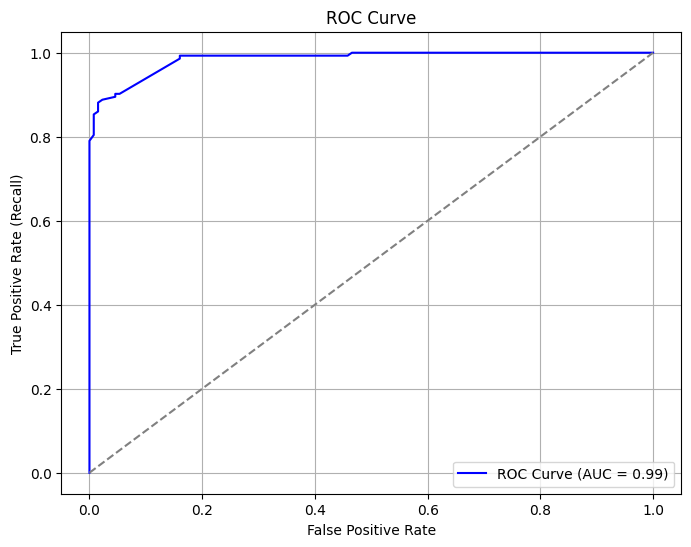

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

**Explanation:**

- roc_curve(y_test, y_prob): Computes the False Positive Rate, True Positive Rate, and thresholds.

- fpr: False Positive Rate values.
- tpr: True Positive Rate values (also called Recall).
- thresholds: Probability cut-off values used to classify observations.
- AUC (Area Under Curve): Measures overall model performance. A higher AUC indicates better classification ability.
- The diagonal dashed line represents a random classifier.

**Interpretation:**
- A curve closer to the top-left corner indicates better model performance.
- If the ROC curve lies above the diagonal line, the model performs better than random guessing.

**Graph Analysis:**

- The **blue ROC curve** stays very close to the **top-left corner**, which indicates excellent classification performance.

- The model achieves a **high True Positive Rate** while maintaining a **low False Positive Rate**.

- The **AUC (Area Under Curve) = 0.99**, which is considered outstanding.  

- An AUC value close to **1.0** means the model can almost perfectly distinguish between the two classes.

- The **gray dashed diagonal line** represents random guessing. Since the ROC curve is far above this line, the model performs significantly better than a random classifier.

**Conclusion:**

This graph indicates that the model is highly accurate and reliable for classification. With an **AUC of 0.99**, the classifier has excellent predictive power and is performing exceptionally well on the test dataset.


**Confusion Matrix**

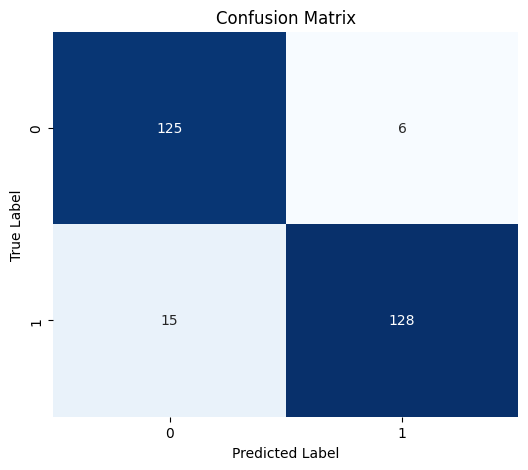

In [24]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Confusion Matrix Visualization and Interpretation

The confusion matrix provides a detailed summary of the classification model’s predictions by comparing the **actual labels** with the **predicted labels**.

**Explanation:**
- **125 True Negatives (TN):** Correctly predicted class 0.  
- **6 False Positives (FP):** Incorrectly predicted class 1 when actual class was 0.  
- **15 False Negatives (FN):** Incorrectly predicted class 0 when actual class was 1.  
- **128 True Positives (TP):** Correctly predicted class 1.  

**Graph Analysis:**
- Most predictions are concentrated in the diagonal cells (**125** and **128**), which indicates correct classifications.
- The off-diagonal values (**6** and **15**) are relatively small, showing few misclassifications.
- The model performs well for both classes with balanced results.

**Performance Insight:**
- High number of **True Positives** and **True Negatives** suggests strong overall accuracy.
- Low **False Positives** and **False Negatives** indicate reliable predictions.
- Since False Negatives (15) are slightly higher than False Positives (6), the model misses some positive cases more often than it incorrectly labels negatives as positives

**Conclusion:**
This confusion matrix shows that the model has strong classification performance with only a small number of errors. Overall, the classifier is accurate, balanced, and dependable for predicting both classes.

